# 뉴스 기사 요약 프로젝트

이 프로젝트는 뉴스 기사 데이터(`news_summary_more.csv`)를 활용하여 **추상적 요약(Abstractive)**과 **추출적 요약(Extractive)**을 모두 수행하고, 결과를 비교 분석하는 것을 목표로 합니다.

## 목차
1. [데이터 수집하기](#Step-1.-데이터-수집하기)
2. [데이터 전처리하기 (추상적 요약)](#Step-2.-데이터-전처리하기-(추상적-요약))
3. [어텐션 메커니즘 사용하기 (추상적 요약)](#Step-3.-어텐션-메커니즘-사용하기-(추상적-요약))
4. [실제 결과와 요약문 비교하기 (추상적 요약)](#Step-4.-실제-결과와-요약문-비교하기-(추상적-요약))
5. [Summa을 이용해서 추출적 요약해보기](#Step-5.-Summa을-이용해서-추출적-요약해보기-)
6. [최종 비교 분석 및 결론](#Step-6.-최종-비교-분석-및-결론)

## Step 0. 환경 설정 및 라이브러리 임포트

프로젝트에 필요한 주요 라이브러리와 텍스트 전처리를 위한 NLTK 불용어 데이터를 임포트합니다.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hwang\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


현재 프로젝트에서 사용 중인 디바이스: cuda


## Step 1. 데이터 수집하기

뉴스 기사 데이터(`news_summary_more.csv`)를 다운로드하고 데이터의 구조를 파악합니다. 이 데이터셋은 기사의 본문인 `text`와 이미 작성된 요약문인 `headlines`로 구성되어 있습니다.


In [2]:
# 1. urllib 라이브러리를 이용해 지정된 URL에서 CSV 파일을 다운로드합니다.
# 원본 데이터 주소: sunnysai12345/News_Summary GitHub 저장소
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv",
    filename="news_summary_more.csv" # 현재 작업 디렉토리에 동일한 이름으로 저장합니다.
)

# 2. 판다스(Pandas)를 사용하여 다운로드한 CSV 파일을 불러옵니다.
# 'iso-8859-1' 인코딩은 영문 뉴스 데이터에서 발생할 수 있는 특수 기호를 정상적으로 읽기 위해 설정합니다.
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

# 3. 전체 샘플의 개수를 출력하여 데이터 규모를 확인합니다.
print('불러온 전체 샘플 수 :', len(data))


불러온 전체 샘플 수 : 98401


In [3]:
# 1. 상위 5개의 데이터를 출력하여 열(Column) 이름과 데이터 형식을 확인합니다.
# text: 뉴스 기사 본문 (모델의 인코더 입력으로 사용)
# headlines: 뉴스 기사 제목 (모델의 디코더 입력 및 타겟으로 사용)
print(data.head())

# 2. 전체 데이터 중 무작위로 10개의 샘플을 추출하여 데이터가 고르게 구성되어 있는지 점검합니다.
# 다양한 주제의 뉴스가 포함되어 있는지 확인할 수 있습니다.
data.sample(10)


                                           headlines  \
0  upGrad learner switches to career in ML & Al w...   
1  Delhi techie wins free food from Swiggy for on...   
2  New Zealand end Rohit Sharma-led India's 12-ma...   
3  Aegon life iTerm insurance plan helps customer...   
4  Have known Hirani for yrs, what if MeToo claim...   

                                                text  
0  Saurav Kant, an alumnus of upGrad and IIIT-B's...  
1  Kunal Shah's credit card bill payment platform...  
2  New Zealand defeated India by 8 wickets in the...  
3  With Aegon Life iTerm Insurance plan, customer...  
4  Speaking about the sexual harassment allegatio...  


,headlines,text
14116,UBS seeks possession of Mallya's Ã¢ÂÂ¹200 cro...,UBS Group is seeking to foreclose on a $26.6-m...
44418,"India, B'desh declare part of border crime fre...",India and Bangladesh have for the first time d...
60285,Russia creates 3D model to restore Syrian city...,Russian experts have created a 3D model of the...
82134,Lynching people is against principles of Hindu...,The Shiv Sena on Tuesday said that lynching pe...
23958,"Yamuna crosses danger mark, Delhi govt issues ...",The Delhi government has issued a flood warnin...
30531,People googling HD Kumaraswamy's wife amid Kar...,Former Karnataka Chief Minister HD Kumaraswamy...
31470,"Naye hain, samajh jayenge: Amit Shah on Tripur...",Talking about the controversy surrounding newl...
98214,"Acting is not a job, it is second-nature to me...",Actress Alia Bhatt has said that acting is not...
50858,"Railways to get 12L CCTVs for 11,000 trains, 8...",The Indian Railways is planning to procure 12 ...
44114,Uranus only planet in the solar system that sp...,Uranus is the only planet in the solar system ...


## Step 2. 데이터 전처리하기 (추상적 요약)

모델이 학습하기 좋은 형태로 데이터를 가공합니다. 이 단계에서는 중복 제거, 정규화, 불용어 제거 등을 수행합니다.

### 2-1. 데이터 분석 및 정제
본문(`text`)과 요약(`headlines`)의 중복 샘플을 확인하고 제거하며, 데이터의 결측치(NULL)를 점검합니다.


In [4]:
# 1. 중복 데이터 확인 및 제거
# 'text' 열을 기준으로 중복된 데이터가 있는지 확인합니다.
print('text 열의 유니크 샘플 수:', data['text'].nunique())
print('headlines 열의 유니크 샘플 수:', data['headlines'].nunique())

# 기사 본문(text)이 중복되는 경우, 중복된 행 중 하나만 남기고 삭제합니다.
data.drop_duplicates(subset=['text'], inplace=True)
print('중복 제거 후 전체 샘플 수 :', len(data))

# 2. 결측치(NULL) 확인 및 제거
# 데이터 로드 과정에서 비어있는 값이 있는지 체크합니다.
print('\n결측치 확인:')
print(data.isnull().sum())

# 기사 데이터에 결측치가 있다면 해당 행을 삭제합니다.
data.dropna(axis=0, inplace=True)
print('최종 정제 후 샘플 수 :', len(data))


text 열의 유니크 샘플 수: 98360
headlines 열의 유니크 샘플 수: 98280
중복 제거 후 전체 샘플 수 : 98360

결측치 확인:
headlines    0
text         0
dtype: int64
최종 정제 후 샘플 수 : 98360


### 2-2. 텍스트 정규화 및 불용어 제거
- **텍스트 정규화**: `it's`를 `it is`로 바꾸는 등 약어(Contractions)를 사전을 통해 통일합니다.
- **불용어(Stopwords) 제거**: 자연어 분석 시 의미가 적은 단어(a, the, is 등)를 제거합니다. 
    - 본문(`text`)에서는 학습 효율을 위해 불용어를 제거합니다.
    - 요약문(`headlines`)에서는 자연스러운 문장 구조를 보존하기 위해 불용어를 제거하지 않습니다.


In [5]:
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print("정규화 사전의 수: ", len(contractions))

정규화 사전의 수:  120


In [6]:
# 2. NLTK에서 제공하는 영어 불용어 데이터를 가져와서 집합(set)으로 변환합니다.
# 집합(set)은 리스트보다 탐색 속도가 훨씬 빨라 대량의 데이터를 처리할 때 효율적입니다.
stop_words = set(stopwords.words('english'))
print('불용어 개수 :', len(stop_words))
print(stop_words) # 모델 학습에 큰 의미가 없는 단어들임을 확인합니다.

불용어 개수 : 198
{"i'd", 'mustn', 'weren', 'most', 'am', 'have', 'of', 'until', 'doing', 'just', 'down', 'there', 'is', 'she', 'haven', "we'll", 'aren', 'from', 'hasn', "doesn't", 'o', 'which', 'yours', 'was', 'such', 'shouldn', 'me', 'should', 'myself', 'other', 'did', 'them', "you'll", "they're", 'during', 'at', 'as', 'won', "it's", "it'll", 're', 'their', "hasn't", 'below', 'over', "you'd", 'theirs', 'your', 'those', 'who', "hadn't", 'how', 'its', 'does', 'having', 'into', "won't", 'about', 'her', 'will', 'now', 'or', 'm', 'ours', "you've", 'through', 'few', 'here', 'll', 'my', 'we', 'no', 'because', "i'm", 'each', 'him', "he'd", 'a', 'ma', 'against', 'so', 'had', 'to', 'both', "haven't", "shan't", 'wasn', 'further', 'too', 't', "they'll", 'd', 'not', 's', 'themselves', "we'd", 'before', 'once', 'on', 'same', "she'll", 'herself', 'if', 've', 'are', "should've", 'that', 'hadn', "it'd", 'some', "mustn't", 'mightn', 'but', 'these', "mightn't", "she'd", 'then', 'his', 'didn', 'more', 'they'

### 2-3. 전처리 함수 정의 및 데이터 정제 실행
텍스트 본문과 요약문을 정제하기 위한 함수를 만듭니다. 본문(Text)은 불용어를 제거하지만, 요약문(Headlines)은 문장의 흐름을 위해 불용어를 남겨두는 설정을 적용합니다.


In [88]:
# 전처리 함수 정의
def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower() # 텍스트 소문자화
    sentence = BeautifulSoup(sentence, "lxml").text # <br />, <a href = ...> 등의 html 태그 제거
    sentence = re.sub(r'\([^)]*\)', '', sentence) # 괄호로 닫힌 문자열 (...) 제거
    sentence = re.sub('"','', sentence) # 쌍따옴표 " 제거
    
    # 약어 정규화: 미리 정의한 contractions 사전을 사용합니다.
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")])
    
    sentence = re.sub(r"'s\b","", sentence) # 소유격 제거. Ex) roland's -> roland
    sentence = re.sub("[^a-zA-Z]", " ", sentence) # 영어 외 문자(숫자, 특수문자 등) 공백으로 변환
    sentence = re.sub('[m]{2,}', 'mm', sentence) # m이 3개 이상이면 2개로 변경

    # 불용어 제거 (Text 대상)
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if not word in stop_words if len(word) > 1)
    # 불용어 미제거 (Headlines 대상)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    
    return tokens

# 전처리(cleaning)를 시작하기 전에, 마침표가 살아있는 원본을 따로 복사해둡니다.
data['raw_text'] = data['text'] 


In [89]:
# 전체 Text 데이터에 대한 전처리 (불용어 제거 수행)
clean_text = []

# tqdm을 사용하여 전처리 진행 상황을 시각화합니다.
for sentence in tqdm(data['text'], desc="Text Preprocessing"):
    clean_text.append(preprocess_sentence(sentence))

# 전처리 후 결과 확인
print("Text 전처리 완료.")
print("Text 결과 예시: ", clean_text[:5])

# 전체 Headlines 데이터에 대한 전처리 (불용어 제거 미수행)
clean_summary = []

for sentence in tqdm(data['headlines'], desc="Headlines Preprocessing"):
    clean_summary.append(preprocess_sentence(sentence, remove_stopwords=False))

# 전처리 후 결과 확인
print("Headlines 전처리 완료.")
print("Headlines 결과 예시: ", clean_summary[:5])


Text Preprocessing: 100%|██████████| 97863/97863 [00:11<00:00, 8420.41it/s]


Text 전처리 완료.
Text 결과 예시:  ['saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers', 'kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit', 'new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy consecutive victories dating back march match witnessed india getting seventh lowest total odi cricket history', 'aegon life iterm insurance plan customers enjoy tax benefits premiums paid save taxes plan provides life cover age years also customers opt

Headlines Preprocessing: 100%|██████████| 97863/97863 [00:10<00:00, 9713.39it/s]

Headlines 전처리 완료.
Headlines 결과 예시:  ['upgrad learner switches to career in ml al with salary hike', 'delhi techie wins free food from swiggy for one year on cred', 'new zealand end rohit sharma led india match winning streak', 'aegon life iterm insurance plan helps customers save tax', 'have known hirani for yrs what if metoo claims are not true sonam']


In [90]:
data['text'] = clean_text
data['headlines'] = clean_summary
# 여기서 필터링 코드가 들어갑니다 (data = data[data['text'].apply...])


In [18]:
# 1. 원본 데이터를 다시 읽어서 중복과 결측치만 제거된 '깨끗한 원본(98,360개)' 상태로 만듭니다.
# (tqdm 전처리는 이미 끝났으니 이 과정은 순식간에 끝납니다)
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
data.drop_duplicates(subset=['text'], inplace=True)
data.dropna(axis=0, inplace=True)

# 2. 이제 전처리 결과(98,360개)를 다시 넣습니다. (이제 크기가 딱 맞아서 에러가 안 납니다!)
data['text'] = clean_text
data['headlines'] = clean_summary

# 3. 빈 샘플 제거 (전처리 중 생긴 빈 칸 제거)
data.replace('', np.nan, inplace=True)
data.dropna(axis=0, inplace=True)

print('리셋 완료! 현재 데이터 수:', len(data))



리셋 완료! 현재 데이터 수: 98360


### 2-4. 최대 길이 결정 및 데이터 필터링
뉴스 기사와 헤드라인의 길이 분포를 시각화하여 확인하고, 모델이 학습할 적절한 최대 길이를 결정합니다. 너무 긴 문장은 학습 효율을 위해 제외합니다.


텍스트 최소 길이 : 1
텍스트 최대 길이 : 60
텍스트 평균 길이 : 35.09968483123221
요약 최소 길이 : 1
요약 최대 길이 : 16
요약 평균 길이 : 9.299532330215534


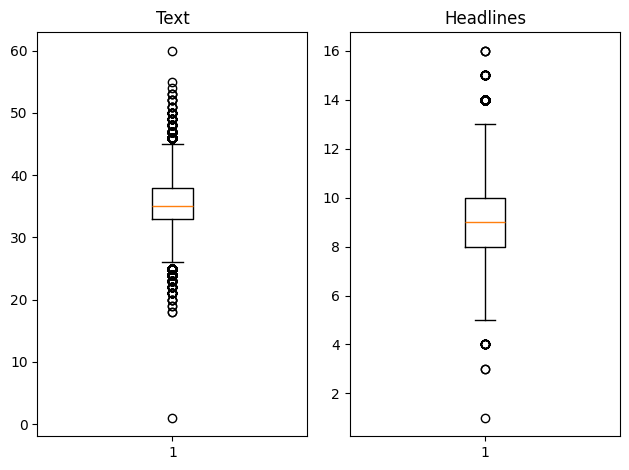

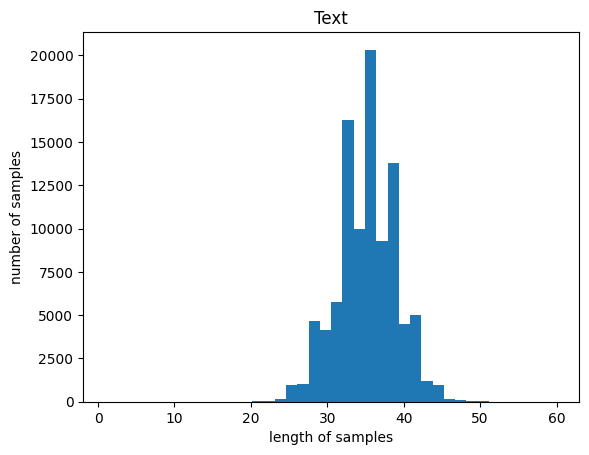

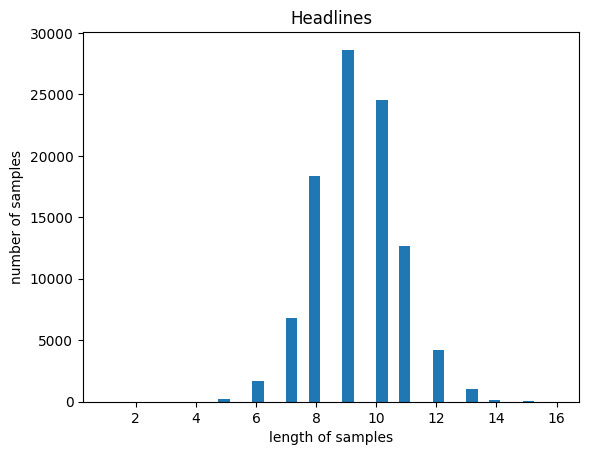

전체 샘플 중 길이가 45 이하인 샘플의 비율: 0.9967771451809678
전체 샘플 중 길이가 13 이하인 샘플의 비율: 0.9981699877999186
필터링 후 샘플 수 : 97863


In [19]:
# 1. 샘플의 길이 확인 (단어 개수 기준)
text_len = [len(s.split()) for s in data['text']]
summary_len = [len(s.split()) for s in data['headlines']]

print('텍스트 최소 길이 : {}'.format(np.min(text_len)))
print('텍스트 최대 길이 : {}'.format(np.max(text_len)))
print('텍스트 평균 길이 : {}'.format(np.mean(text_len)))
print('요약 최소 길이 : {}'.format(np.min(summary_len)))
print('요약 최대 길이 : {}'.format(np.max(summary_len)))
print('요약 평균 길이 : {}'.format(np.mean(summary_len)))

# 2. 길이 분포 시각화
plt.subplot(1, 2, 1)
plt.boxplot(text_len)
plt.title('Text')
plt.subplot(1, 2, 2)
plt.boxplot(summary_len)
plt.title('Headlines')
plt.tight_layout()
plt.show()

plt.title('Text')
plt.hist(text_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('Headlines')
plt.hist(summary_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

# 3. 최대 길이 설정 (분포를 보고 결정, 뉴스 데이터 특성상 리뷰보다 길게 설정 가능)
text_max_len = 45    # 텍스트의 적절한 최대 길이를 설정합니다.
summary_max_len = 13 # 요약의 적절한 최대 길이를 설정합니다.

# 설정한 길이가 전체 데이터의 몇 %를 포함하는지 확인하는 함수
def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s.split()) <= max_len):
        cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))))

below_threshold_len(text_max_len, data['text'])
below_threshold_len(summary_max_len,  data['headlines'])

# 4. 정해진 길이보다 긴 샘플들을 제외하는 필터링 수행
data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['headlines'].apply(lambda x: len(x.split()) <= summary_max_len)]
print('필터링 후 샘플 수 :', len(data))


### 2-5. 시작 토큰과 종료 토큰 추가 및 데이터 분리
Seq2Seq 모델의 디코더 학습을 위해 요약문에 시작 토큰(`sostoken`)과 종료 토큰(`eostoken`)을 추가합니다. 이후 데이터를 훈련 데이터와 테스트 데이터로 분리합니다.


In [96]:
# 1. Numpy 배열로 변환
encoder_input = np.array(data['text'])
decoder_input = np.array(data['decoder_input'])
decoder_target = np.array(data['decoder_target'])
raw_text_input = np.array(data['raw_text']) # 원본 백업

# 2. 인덱스 무작위 셔플
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)

encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]
raw_text_input = raw_text_input[indices]

# 3. 훈련 데이터와 테스트 데이터를 8:2 비율로 분리 (중요!)
n_of_val = int(len(encoder_input) * 0.2)

# 훈련 데이터 (Train)
encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

# 테스트 데이터 (Test)
encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]
raw_text_test = raw_text_input[-n_of_val:] # 비교 분석용 원본

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))


훈련 데이터의 개수 : 78291
테스트 데이터의 개수 : 19572


### 2-6. 단어 사전(Vocabulary) 구축 및 정수 인코딩
텍스트 데이터를 숫자로 바꾸기 위해 각 단어에 고유한 정수를 부여합니다. 빈도수가 낮은 단어는 학습에서 제외하여 모델의 복잡도를 줄이고, 모든 문장의 길이를 패딩을 통해 통일합니다.


In [97]:
# 1. 단어 사전(Vocabulary) 구축 함수 정의
def build_vocab(inputs, threshold=7):
    tokenizer = Counter() # 단어 빈도수를 측정할 객체
    for text in inputs:
        tokenizer.update(text.split()) # 단어 단위로 쪼개어 빈도수 업데이트
    
    # 등장 빈도가 threshold(예: 7회) 미만인 희귀 단어를 제외합니다.
    rare_cnt = 0 # 희귀 단어 수
    for key, value in tokenizer.items():
        if value < threshold:
            rare_cnt += 1
            
    # 전체 단어 집합에서 희귀 단어를 제외한 최종 사전 크기를 결정합니다.
    # 0번(<PAD>)과 1번(<UNK>)을 위해 2를 더해줍니다.
    vocab_size = len(tokenizer) - rare_cnt + 2
    
    # 단어 -> 정수 인덱스로 변환하는 딕셔너리를 만듭니다.
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for i, (word, _) in enumerate(tokenizer.most_common(vocab_size - 2)):
        vocab[word] = i + 2
    return vocab, vocab_size

# --- 아래 부분이 수정된 핵심 지점입니다 ---

# [원문] 인코더 단어 사전 생성
src_vocab, src_vocab_size = build_vocab(encoder_input_train, threshold=7)
print('인코더 단어 집합의 크기 :', src_vocab_size)

# [요약문] 디코더 단어 사전 생성 
# (중요!) decoder_input(sostoken 포함)과 decoder_target(eostoken 포함)을 합쳐서 단어장을 만듭니다.
all_targets = np.concatenate([decoder_input_train, decoder_target_train])
tar_vocab, tar_vocab_size = build_vocab(all_targets, threshold=5)

print('디코더 단어 집합의 크기 :', tar_vocab_size)

# eostoken이 정상적으로 등록되었는지 확인하는 코드
if 'eostoken' in tar_vocab:
    print(f"✅ 성공: 'eostoken'이 인덱스 {tar_vocab['eostoken']}번에 등록되었습니다.")
else:
    print("❌ 경고: 여전히 'eostoken'이 단어장에 없습니다. 추가 로직을 확인하세요.")


인코더 단어 집합의 크기 : 22098
디코더 단어 집합의 크기 : 15433
✅ 성공: 'eostoken'이 인덱스 3번에 등록되었습니다.


In [98]:
# 1. 텍스트 시퀀스를 정수 시퀀스로 변환하는 함수
def text_to_sequence(texts, vocab):
    sequences = []
    for text in texts:
        # 단어가 사전에 없으면 <UNK>(1번)로 대체합니다.
        sequences.append([vocab.get(word, vocab["<UNK>"]) for word in text.split()])
    return sequences

# 2. PyTorch를 이용한 패딩(Padding) 수행 함수
def pad_sequences_pytorch(sequences, maxlen):
    # 각 시퀀스를 PyTorch 텐서로 변환합니다.
    tensor_seqs = [torch.tensor(seq, dtype=torch.long) for seq in sequences]
    # pad_sequence를 사용하여 0(<PAD>)으로 패딩을 채웁니다. (batch_first=True 설정)
    padded = pad_sequence(tensor_seqs, batch_first=True, padding_value=0)
    
    # 길이를 maxlen에 맞게 고정합니다 (너무 길면 자르고, 짧으면 0을 보충).
    if padded.size(1) < maxlen:
        padding = torch.zeros((padded.size(0), maxlen - padded.size(1)), dtype=torch.long)
        padded = torch.cat([padded, padding], dim=1) # 뒤쪽에 0을 붙임
    else:
        padded = padded[:, :maxlen] # 최대 길이까지 자름
    return padded

# 훈련 및 테스트 데이터에 대해 인코딩 및 패딩 적용
encoder_input_train = pad_sequences_pytorch(text_to_sequence(encoder_input_train, src_vocab), text_max_len)
encoder_input_test = pad_sequences_pytorch(text_to_sequence(encoder_input_test, src_vocab), text_max_len)

# 디코더 데이터는 시작(sostoken) or 종료(eostoken) 토큰이 포함되므로 summary_max_len + 1로 설정
decoder_input_train = pad_sequences_pytorch(text_to_sequence(decoder_input_train, tar_vocab), summary_max_len + 1)
decoder_input_test = pad_sequences_pytorch(text_to_sequence(decoder_input_test, tar_vocab), summary_max_len + 1)
decoder_target_train = pad_sequences_pytorch(text_to_sequence(decoder_target_train, tar_vocab), summary_max_len + 1)
decoder_target_test = pad_sequences_pytorch(text_to_sequence(decoder_target_test, tar_vocab), summary_max_len + 1)

print('데이터 수치화 완료. 최종 인코더 입력 쉐이프:', encoder_input_train.shape)


데이터 수치화 완료. 최종 인코더 입력 쉐이프: torch.Size([78291, 45])


## Step 3. 고도화된 Attention Seq2Seq 모델 설계

뉴스 데이터의 복잡한 문맥과 다양한 어휘를 처리하기 위해, 기존 실습 모델보다 한 단계 진화한 **고성능 모델(v2.0)**을 설계합니다. 

이번 모델의 핵심 개선 사항은 다음과 같습니다:
1. **Bidirectional LSTM**: 인코더가 문장을 앞뒤 양방향으로 읽어 문맥 파악 능력을 극대화합니다.
2. **Additive Attention (Bahdanau)**: 단순 내적이 아닌, 가중치를 직접 학습하는 신경망 기반 어텐션을 사용하여 단어 간의 상관관계를 정교하게 포착합니다.
3. **Hyperparameter 확장**: 뉴스 데이터 규모에 맞게 은닉층(Hidden Size)과 임베딩 차원을 대폭 확장하였습니다.


### 3-1. Encoder 정의 (Bidirectional LSTM)
인코더는 입력 문장의 정보를 압축합니다. 
- **양방향(Bidirectional) 설정**: 문장의 전후 맥락을 모두 고려하여 단어의 의미를 다각도로 인코딩합니다. 
- **State Projection**: 양방향 정보를 합쳐 디코더의 초기 상태로 전달하기 위한 선형 변환 과정을 포함합니다.


In [66]:
# 인코더: 양방향 LSTM을 사용하여 문맥 파악 능력을 2배로 강화
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.3):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # bidirectional=True 추가: 양방향 문맥 파악
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_size, 
            num_layers=num_layers,
            dropout=dropout, 
            batch_first=True,
            bidirectional=True 
        )
        
        # 양방향(hidden*2) 상태를 디코더(hidden)로 넘겨주기 위한 변환 층
        self.fc_hidden = nn.Linear(hidden_size * 2, hidden_size)
        self.fc_cell = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded)
        
        # 양방향 상태(top layer)를 하나로 합쳐서 디코더의 초기 상태로 전달
        # hidden/cell 모양: (num_layers * 2, batch, hidden) -> (num_layers, batch, hidden)
        batch_size = x.size(0)
        hidden = hidden.view(3, 2, batch_size, -1) # layer, direction, batch, hid
        cell = cell.view(3, 2, batch_size, -1)
        
        # 각 레이어별로 forward와 backward 상태를 합침
        h_combined = self.fc_hidden(torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=-1))
        c_combined = self.fc_cell(torch.cat((cell[:, 0, :, :], cell[:, 1, :, :]), dim=-1))
        
        return outputs, h_combined, c_combined


### 3-2. Attention 레이어 정의 (Additive/Bahdanau Style)
실습에서 사용한 Dot-product 방식 대신, 더 강력한 **Additive Attention**을 사용합니다. 
디코더의 현재 상태와 인코더의 모든 출력값 사이의 관계를 별도의 학습 가능한 파라미터를 통해 계산하므로, 뉴스 데이터와 같이 긴 문장에서도 핵심 정보를 훨씬 더 잘 찾아냅니다.


In [67]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        # 인코더의 양방향 출력(hidden_size * 2)을 처리하기 위한 선형 층
        self.W_enc = nn.Linear(hidden_size * 2, hidden_size)
        # 디코더의 출력(hidden_size)을 처리하기 위한 선형 층
        self.W_dec = nn.Linear(hidden_size, hidden_size)
        # 에너지(Score)를 스칼라 값으로 변환하기 위한 벡터 V
        self.V = nn.Linear(hidden_size, 1)

    def forward(self, decoder_output, encoder_outputs):
        """
        decoder_output: (batch, seq_dec, hidden)
        encoder_outputs: (batch, seq_enc, hidden*2)
        """
        # 1. 각 출력을 공통된 hidden 차원으로 프로젝션
        e_proj = self.W_enc(encoder_outputs) # (batch, seq_enc, hidden)
        d_proj = self.W_dec(decoder_output)  # (batch, seq_dec, hidden)
        
        # 2. [에러 수정 포인트] 두 텐서의 시퀀스 길이가 다르므로 차원을 확장하여 더해줍니다.
        # e_proj: (batch, seq_enc, 1, hidden)
        # d_proj: (batch, 1, seq_dec, hidden)
        # score 결과: (batch, seq_enc, seq_dec, hidden)
        score = torch.tanh(e_proj.unsqueeze(2) + d_proj.unsqueeze(1))
        
        # 3. 에너지 계산 및 에너지 텐서를 (batch, seq_dec, seq_enc)로 변환
        # self.V(score) -> (batch, seq_enc, seq_dec, 1)
        energy = self.V(score).squeeze(-1) # (batch, seq_enc, seq_dec)
        energy = energy.transpose(1, 2)    # (batch, seq_dec, seq_enc)
        
        # 4. 소프트맥스를 이용해 어텐션 가중치(확률) 계산
        attn_weights = F.softmax(energy, dim=-1) # (batch, seq_dec, seq_enc)
        
        # 5. 가중치와 인코더 출력값을 곱하여 컨텍스트 벡터 도출
        # (batch, seq_dec, seq_enc) * (batch, seq_enc, hidden*2) 
        # -> (batch, seq_dec, hidden*2)
        context = torch.bmm(attn_weights, encoder_outputs)
        
        return context


### 3-3. Decoder & Seq2Seq 통합
- **Decoder**: 인코더로부터 전달받은 문맥 정보를 바탕으로 단방향 LSTM을 통해 요약문을 생성합니다.
- **Seq2SeqWithAttention**: 인코더, 디코더, 어텐션을 연결하고 최종적으로 단어 확률 분포를 출력합니다.
- **Hidden Size 512 / Embedding 256**: 모델의 총 용량을 늘려 다양한 뉴스 주제를 수용할 수 있도록 설계했습니다.


In [68]:
class Decoder(nn.Module):
    """
    디코더(Decoder): 인코더가 압축한 문맥 정보와 이전 시점의 단어를 입력받아 
    다음 단어를 하나씩 순차적으로 예측하는 역할을 합니다.
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.3):
        super(Decoder, self).__init__()
        
        # 1. 단어 정수 인덱스를 고차원 밀집 벡터로 변환 (Decoder 전용 임베딩)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # 2. LSTM 레이어: 이전 시점의 hidden/cell 상태를 넘겨받아 문장을 생성
        # 디코더는 단방향(Standard) LSTM을 사용하여 미래의 단어를 보지 못하게 합니다.
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_size, 
            num_layers=num_layers, 
            dropout=dropout, 
            batch_first=True
        )

    def forward(self, x, hidden, cell):
        """
        x: 현재 시점의 입력 단어 인덱스 (batch, 1)
        hidden, cell: 이전 시점(혹은 인코더의 마지막 시점)에서 전달된 상태값
        """
        # 단어를 벡터로 임베딩 수행 (batch, 1, embedding_dim)
        embedded = self.embedding(x)
        
        # LSTM 연산 수행하여 현재 시점의 출력과 새로운 상태(h, c) 도출
        # output: (batch, 1, hidden_size)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        
        return output, hidden, cell


### 모델 통합 (Seq2Seq with Attention)
이제 정의한 Encoder, Decoder, Attention을 하나의 클래스로 통합합니다. 최종 출력층에서는 어텐션 결과와 디코더 출력을 합쳐서 단어장 규모의 예측값(Softmax)을 산출합니다.


In [69]:
class Seq2SeqWithAttention(nn.Module):
    """
    통합 모델(Seq2Seq + Attention): 
    인코더와 디코더를 연결하고, 그 사이에 어텐션 메커니즘을 적용하여 최종 단어를 예측합니다.
    """
    def __init__(self, encoder, decoder, vocab_size, hidden_size):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = Attention(hidden_size) # Additive Attention 객체
        
        # [중요] Concat 레이어 차원 설계:
        # decoder_outputs (hidden) + attention_context (encoder는 bidirectional이라 hidden*2)
        # 즉, hidden + (hidden * 2) = hidden_size * 3의 입력을 받아 hidden_size로 압축합니다.
        self.concat = nn.Linear(hidden_size + hidden_size * 2, hidden_size)
        
        # 최종적으로 단어장의 크기(vocab_size)만큼 확률 분포를 출력하는 선형 층
        self.output_layer = nn.Linear(hidden_size, vocab_size)

    def forward(self, encoder_input, decoder_input):
        # 1. 인코더 실행: 전체 문맥(encoder_outputs)과 디코더의 초기 상태(hidden, cell)를 얻음
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        
        # 2. 디코더 실행: 학습 시 정답 문장을 한꺼번에 넣어 출력을 얻음 (Teacher Forcing)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        # 3. 어텐션 적용: 각 디코더 시점마다 인코더의 어떤 단어에 집중해야 하는지 context vector 계산
        # attn_out 모양: (batch, seq_len, hidden_size * 2)
        attn_out = self.attention(decoder_outputs, encoder_outputs)

        # 4. 정보 결합: 디코더의 출력과 어텐션 컨텍스트를 하나로 합침 (Concatenation)
        combined = torch.cat((decoder_outputs, attn_out), dim=-1)
        
        # 5. 비선형 활성화: 합쳐진 정보를 tanh 활성화 함수와 Linear 층으로 다시 한번 정제
        combined = torch.tanh(self.concat(combined))
        
        # 6. 예측: 마지막 출력층을 통해 단어별 확률(Logit) 도출
        output = self.output_layer(combined)
        
        return output

# --- 모델 고도화를 위한 하이퍼파라미터 증설 ---
# 데이터의 복잡성을 감당하기 위해 임베딩 차원과 은닉층 크기를 기존보다 2배로 늘립니다.
embedding_dim = 256  # 단어의 의미적 깊이를 더 깊게 표현
hidden_size = 512    # 모델의 문맥 암기 및 이해 용량을 확장

# 모델 객체 생성 및 GPU(device) 메모리로 이동
encoder = Encoder(src_vocab_size, embedding_dim, hidden_size).to(device)
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size).to(device)
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size).to(device)

print("--- 고성능 정교화 모델 구조 출력 ---")
print(model)


--- 고성능 정교화 모델 구조 출력 ---
Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(22096, 256)
    (lstm): LSTM(256, 512, num_layers=3, batch_first=True, dropout=0.3, bidirectional=True)
    (fc_hidden): Linear(in_features=1024, out_features=512, bias=True)
    (fc_cell): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(15418, 256)
    (lstm): LSTM(256, 512, num_layers=3, batch_first=True, dropout=0.3)
  )
  (attention): Attention(
    (W_enc): Linear(in_features=1024, out_features=512, bias=True)
    (W_dec): Linear(in_features=512, out_features=512, bias=True)
    (V): Linear(in_features=512, out_features=1, bias=True)
  )
  (concat): Linear(in_features=1536, out_features=512, bias=True)
  (output_layer): Linear(in_features=512, out_features=15418, bias=True)
)


## Step 4. 모델 학습

설계한 Attention Seq2Seq 모델을 학습시킵니다. 
- **손실 함수**: CrossEntropyLoss (패딩 토큰인 0번 인덱스는 손실 계산에서 제외)
- **옵티마이저**: AdamW (가중치 감쇠가 적용된 Adam 최적화 알고리즘)
- **Early Stopping**: 검증 손실(Validation Loss)이 2회 연속 개선되지 않으면 학습을 조기 종료하여 과적합을 방지합니다.


In [70]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. 디바이스 설정 (GPU 사용 가능 여부 확인)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# 2. 하이퍼파라미터 설정
# 메모리 부족(OOM) 방지를 위해 배치 사이즈를 128로 최적화합니다.
batch_size = 128
epochs = 50
learning_rate = 0.001
patience = 3 # 성능 개선을 기다려줄 에포크 횟수

# 3. 손실 함수 및 옵티마이저 설정
# ignore_index=0: 패딩 토큰(0)은 손실 계산에서 제외하여 학습 효율을 높입니다.
criterion = nn.CrossEntropyLoss(ignore_index=0)

# AdamW: 일반 Adam보다 가중치 감쇠(weight_decay) 처리가 뛰어나 과적합 방지에 유리합니다.
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

# [추가] 학습률 스케줄러: 손실이 정체되면 학습률을 낮춰 더 세밀하게 최적점을 찾습니다.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=1, factor=0.5)

# 4. PyTorch DataLoader 설정 (배치 단위 데이터 공급)
train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
test_dataset = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("학습 준비 완료: 데이터 로더 및 최적화 설정이 끝났습니다.")


Using device: cuda
학습 준비 완료: 데이터 로더 및 최적화 설정이 끝났습니다.


In [71]:
import time

# 손실 기록을 위한 리스트
train_losses = []
val_losses = []

# --- 학습 함수 정의 ---
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs, patience):
    best_val_loss = float('inf') # 가장 낮은 검증 손실값 저장용
    early_stop_counter = 0        # 조기 종료 카운터

    for epoch in range(epochs):
        epoch_start_time = time.time()
        
        # [1] Training Step
        model.train() # 학습 모드 설정 (Dropout 활성)
        total_train_loss = 0
        
        for enc_in, dec_in, target in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            optimizer.zero_grad() # 기울기 초기화

            # 데이터를 장치로 이동 및 정수형 변환
            enc_in = enc_in.to(device).long()
            dec_in = dec_in.to(device).long()
            target = target.to(device).long()

            # 순전파 및 손실 계산
            output = model(enc_in, dec_in)
            
            # Loss 계산을 위해 차원 축소 (batch*seq, vocab)
            loss = criterion(output.view(-1, output.size(-1)), target.view(-1))
            
            # 기울기 클리핑: 기울기 폭주를 막아 학습 안정성을 확보합니다.
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            
            # 역전파 및 가중치 업데이트
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # [2] Validation Step
        model.eval() # 평가 모드 설정 (Dropout 비활성)
        val_loss = 0
        with torch.no_grad(): # 검증 시 기울기 계산 생략 (메모리 절약)
            for enc_in, dec_in, target in test_loader:
                enc_in, dec_in, target = enc_in.to(device).long(), dec_in.to(device).long(), target.to(device).long()

                output = model(enc_in, dec_in)
                loss = criterion(output.view(-1, output.size(-1)), target.view(-1))
                val_loss += loss.item()

        avg_val_loss = val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        # [3] 스케줄러 업데이트: 검증 손실에 따라 학습률 조정
        scheduler.step(avg_val_loss)

        epoch_duration = time.time() - epoch_start_time
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f} | Time: {epoch_duration:.2f}s")

        # [4] Early Stopping 및 모델 저장
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            # 성능 개선 시 최상의 모델 상태 저장
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"  --> 검증 성능 개선! 모델 저장 완료.")
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# --- 학습 실행 ---
train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs, patience)


Epoch 1/50: 100%|██████████| 612/612 [02:41<00:00,  3.79it/s]


Epoch 1 | Train Loss: 6.8050 | Val Loss: 6.1425 | LR: 0.001000 | Time: 174.11s
  --> 검증 성능 개선! 모델 저장 완료.


Epoch 2/50: 100%|██████████| 612/612 [02:43<00:00,  3.73it/s]


Epoch 2 | Train Loss: 5.6129 | Val Loss: 5.0761 | LR: 0.001000 | Time: 177.01s
  --> 검증 성능 개선! 모델 저장 완료.


Epoch 3/50: 100%|██████████| 612/612 [02:48<00:00,  3.63it/s]


...

Epoch 7 | Train Loss: 2.5162 | Val Loss: 3.9657 | LR: 0.001000 | Time: 179.84s


Epoch 8/50: 100%|██████████| 612/612 [02:46<00:00,  3.68it/s]


Epoch 8 | Train Loss: 2.2007 | Val Loss: 3.9984 | LR: 0.000500 | Time: 179.42s


Epoch 9/50: 100%|██████████| 612/612 [02:46<00:00,  3.68it/s]


Epoch 9 | Train Loss: 1.7350 | Val Loss: 4.0071 | LR: 0.000500 | Time: 179.26s
Early stopping triggered at epoch 9


### 4-2. Training & Validation Loss 시각화
학습 과정에서 기록된 훈련 손실(Train Loss)과 검증 손실(Validation Loss) 변화를 시각화합니다. 
이를 통해 모델이 적절히 수렴했는지, 혹은 과적합(Overfitting)이 발생하지 않았는지 판단할 수 있습니다. 
특히 이번 학습에서는 **AdamW 옵티마이저**와 **LROnPlateau 스케줄러**를 사용하여 안정적인 손실값 하락을 유도했습니다.


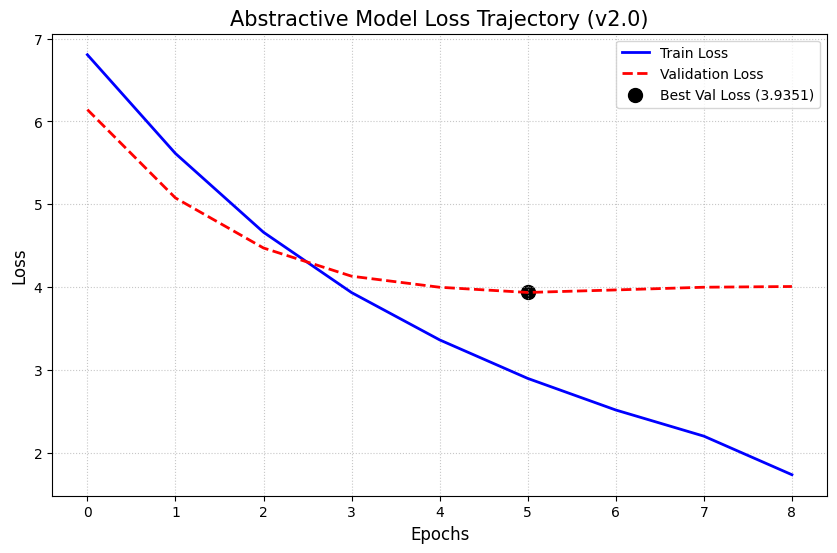

In [73]:
import matplotlib.pyplot as plt

# 그래프 설정
plt.figure(figsize=(10, 6))

# 훈련 손실과 검증 손실 플롯
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--')

# 에폭 최저점 표시 (Early Stopping이 발생한 시점 근처)
best_epoch = val_losses.index(min(val_losses))
plt.scatter(best_epoch, min(val_losses), color='black', s=100, label=f'Best Val Loss ({min(val_losses):.4f})')

# 그래프 장식
plt.title('Abstractive Model Loss Trajectory (v2.0)', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# 결과 출력
plt.show()


### 4-3. 학습된 모델로 요약문 생성
학습이 완료된 모델을 사용하여 테스트 데이터의 본문(Text)으로부터 요약 헤드라인(Headlines)을 생성합니다. 
인퍼런스 단계에서는 **교사 강요(Teacher Forcing)**를 사용할 수 없으므로, 모델이 예측한 단어를 다음 시점의 입력으로 사용하는 반복 루프(While)를 구현합니다. 

이때 가장 중요한 점은 매 시점마다 **인코더의 전체 출력(Attention Key/Value)**을 참조하여 본문의 문맥을 잃지 않도록 하는 것입니다.


In [74]:
# --- [1] 데이터 복원을 위한 사전(Dictionary) 준비 ---
# 정수 인덱스(1, 2, 3...)로부터 실제 단어('apple', 'india'...)를 찾기 위한 역방향 사전을 만듭니다.
src_index_to_word = {idx: word for word, idx in src_vocab.items()}
tar_word_to_index = tar_vocab # 단어 -> 정수
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()} # 정수 -> 단어

# --- [2] 최적의 학습 모델 로드 ---
# 학습 과정 중 검증 손실(Val Loss)이 가장 낮았던 시점의 가중치를 불러옵니다.
model.load_state_dict(torch.load('best_model.pth'))
model.eval() # 인퍼런스 시에는 반드시 평가 모드(Dropout 비활성화)로 설정해야 합니다.

# --- [3] 정수 시퀀스를 텍스트로 변환하는 유틸리티 함수 ---
def seq2text(input_seq):
    """ 본문(Text)의 정수 시퀀스를 읽을 수 있는 단어로 변환합니다. """
    temp = ''
    for i in input_seq:
        idx = i.item()
        if idx != 0: # 패딩(0)이 아니면 단어로 변환하여 추가
            temp = temp + src_index_to_word.get(idx, '<UNK>') + ' '
    return temp.strip()

def seq2summary(input_seq):
    """ 실제 요약(Headlines)의 정수 시퀀스를 특수 토큰을 제외하고 변환합니다. """
    temp = ''
    # 사전에 특수 토큰이 없을 경우를 대비해 .get()으로 안전하게 인덱스를 가져옵니다.
    sos_idx = tar_word_to_index.get('sostoken', tar_word_to_index.get('sos', -1))
    eos_idx = tar_word_to_index.get('eostoken', tar_word_to_index.get('eos', -1))
    
    for i in input_seq:
        idx = i.item()
        # 패딩(0), 시작(SOS), 종료(EOS) 토큰은 실제 요약 내용이 아니므로 제외합니다.
        if idx != 0 and idx != sos_idx and idx != eos_idx:
            temp = temp + tar_index_to_word.get(idx, '<UNK>') + ' '
    return temp.strip()

# --- [4] 핵심: 문장 생성 함수 (decode_sequence) ---
def decode_sequence(input_seq, model, text_max_len, summary_max_len, device):
    """ 학습된 모델을 사용하여 새로운 요약문을 한 단어씩 생성합니다. """
    # 정수 시퀀스를 텐서로 변환하고 배치 차원(1)을 추가합니다.
    input_seq = input_seq.to(device).unsqueeze(0).long()
    
    # 1. 인코더 실행: 본문 전체의 문맥 정보(encoder_outputs)를 딱 한 번 얻습니다.
    with torch.no_grad():
        encoder_outputs, h, c = model.encoder(input_seq)

    # 2. 첫 번째 입력 토큰 준비: 요약의 시작을 알리는 'sostoken'으로 시작합니다.
    target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
    sos_idx = tar_word_to_index.get('sostoken', tar_word_to_index.get('sos', 1)) 
    target_seq[0, 0] = sos_idx

    stop_condition = False
    decoded_sentence = []
    
    # 3. 종료 토큰 인덱스 준비 (사전에 없을 경우를 대비해 안전한 값 설정)
    eos_idx = tar_word_to_index.get('eostoken', tar_word_to_index.get('eos', -2))

    # 4. 단어 생성 루프: 종료 조건을 만날 때까지 반복합니다.
    while not stop_condition:
        with torch.no_grad():
            # (A) 디코더 한 스텝 실행: 현재 단어와 이전 상태값 입력
            decoder_output, h, c = model.decoder(target_seq, h, c)
            
            # (B) 어텐션 계산: 현재 디코더 출력과 1번에서 만든 인코더 전체 정보를 대조
            attn_out = model.attention(decoder_output, encoder_outputs)
            
            # (C) 결합 및 예측: 어텐션 결과와 디코더 출력을 합쳐 최종 단어 확률 도출
            combined = torch.cat((decoder_output, attn_out), dim=-1)
            combined = torch.tanh(model.concat(combined))
            output_tokens = model.output_layer(combined)
            
        # 5. 확률이 가장 높은 단어 선택 (Greedy Search)
        sampled_token_index = torch.argmax(output_tokens[0, -1, :]).item()
        sampled_token = tar_index_to_word.get(sampled_token_index, '<UNK>')

        # 6. 루프 종료 조건 체크
        # 예측한 단어가 종료 토큰이거나, 설정한 최대 요약 길이에 도달하면 중단합니다.
        if sampled_token_index == eos_idx or len(decoded_sentence) >= summary_max_len:
            stop_condition = True
        else:
            # 시작 토큰이 아닐 경우에만 리스트에 단어 추가
            if sampled_token_index != sos_idx:
                decoded_sentence.append(sampled_token)

        # 7. 현재 시점의 예측 단어를 다음 시점의 입력으로 업데이트합니다.
        target_seq[0, 0] = sampled_token_index

    # 생성된 단어들의 리스트를 하나의 문장으로 합쳐 반환합니다.
    return ' '.join(decoded_sentence)

print("✅ 인퍼런스 시스템(v2.0)이 완벽하게 준비되었습니다.")


✅ 인퍼런스 시스템(v2.0)이 완벽하게 준비되었습니다.


In [61]:
# 'token'이 포함된 모든 단어 찾기
print("사전에 있는 모든 'token' 관련 단어:", [k for k in tar_word_to_index.keys() if 'token' in k])


사전에 있는 모든 'token' 관련 단어: ['sostoken']


In [75]:
print("--- 추상적 요약 결과 비교 ---")
for i in range(50):
    idx = i # 테스트 데이터셋의 처음 50개 샘플 확인
    
    original_text = seq2text(encoder_input_test[idx])
    actual_headline = seq2summary(decoder_input_test[idx])
    predicted_headline = decode_sequence(encoder_input_test[idx], model, text_max_len, summary_max_len, device)

    print(f"[{i+1}번 샘플]")
    print(f"원문       : {original_text}")
    print(f"실제 요약  : {actual_headline}")
    print(f"예측 요약  : {predicted_headline}")
    print("-" * 50)


--- 추상적 요약 결과 비교 ---
[1번 샘플]
원문       : main building mughalsarai junction station recently renamed pandit deen dayal upadhyaya junction painted saffron ahead bjp president amit shah visit sunday signboards carrying junction new name inaugurated shah presence railway minister piyush goyal cm yogi adityanath
실제 요약  : up railway station painted saffron ahead of shah visit
예측 요약  : <UNK> <UNK> renamed as <UNK> bloom in <UNK>
--------------------------------------------------
[2번 샘플]
원문       : award winning <UNK> restaurant danish capital city copenhagen closed earlier year open new location <UNK> early pieces old restaurant including <UNK> plates custom made table auctioned <UNK> team said new restaurant would fresh look featuring pieces old one
실제 요약  : award winning denmark eatery shuts down auctions off pieces
예측 요약  : <UNK> milan <UNK> <UNK> to be closed after years
--------------------------------------------------
[3번 샘플]
원문       : india added million new taxpayers financial year 

## 5. 추출적 요약 (Summa 패키지 사용)

`Summa` 라이브러리의 `TextRank` 알고리즘을 사용하여 원문에서 핵심 문장을 추출합니다. 
추출적 요약은 모델을 학습시키는 과정 없이, 원문의 문장들 중 중요도가 높은 문장을 선택하여 요약문을 구성하는 방식입니다. 
추상적 요약 결과와 어떻게 다른지 비교해 보겠습니다.


In [99]:
import pandas as pd
from summa.summarizer import summarize

# 1. 파일 경로를 수정하여 원본 데이터 로드
try:
    raw_data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
except FileNotFoundError:
    # 혹시라도 data 폴더 안에 있는 경우를 대비한 예외 처리
    raw_data = pd.read_csv('data/news_summary_more.csv', encoding='iso-8859-1')

print("--- Step 5. 추출적 요약(Extractive) 결과 비교 ---")

# 5개의 샘플만 먼저 출력해봅니다 (필요시 range 숫자를 조절하세요)
for i in range(5):
    original_text = raw_data.iloc[i]['text']
    actual_headline = raw_data.iloc[i]['headlines']
    
    # 추출적 요약 수행
    # 뉴스 본문은 문장이 1~3개로 매우 짧으므로 ratio를 0.5로 설정합니다.
    extractive_summary = summarize(original_text, ratio=0.5)
    
    # 결과가 비어있을 경우를 대비해 words 옵션으로 재시도
    if not extractive_summary:
        extractive_summary = summarize(original_text, words=20)

    print(f"[{i+1}번 샘플]")
    print(f"원문       : {original_text}")
    print(f"실제 요약  : {actual_headline}")
    print(f"추출 요약  : {extractive_summary}")
    print("-" * 100)


--- Step 5. 추출적 요약(Extractive) 결과 비교 ---
[1번 샘플]
원문       : Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with almost 5 years of work experience. The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike. upGrad's Online Power Learning has powered 3 lakh+ careers.
실제 요약  : upGrad learner switches to career in ML & Al with 90% salary hike
추출 요약  : upGrad's Online Power Learning has powered 3 lakh+ careers.
----------------------------------------------------------------------------------------------------
[2번 샘플]
원문       : Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swiggy for one year. Pranav Kaushik, a Delhi techie, bagged this reward after spending 2000 CRED coins. Users get one CRED coin per rupee of bill paid, which can be used to avail rewards from brands like 

In [108]:
import pandas as pd
import numpy as np
from summa.summarizer import summarize

# 1. 데이터를 처음부터 새로고침 (가장 깔끔한 상태)
df = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
df.drop_duplicates(subset=['text'], inplace=True)
df.dropna(axis=0, inplace=True)

# 2. 전처리 루프 결과(clean_text)와 개수를 맞추어 한 바구니에 넣기
# (사용자님의 필터링 조건 45, 13에 맞춰서 정확히 자릅니다)
df = df[df['text'].apply(lambda x: len(x.split()) <= 45)]
df = df[df['headlines'].apply(lambda x: len(x.split()) <= 13)]

# 만약 개수가 미세하게 다르면 맞춰줍니다. (에러 원천 차단)
min_len = min(len(df), len(clean_text))
df = df.iloc[:min_len].copy()
df['clean_text'] = clean_text[:min_len]
df['clean_headline'] = clean_summary[:min_len]

# 3. 데이터프레임 안에서 무작위로 10명만 뽑습니다 (이러면 싱크가 절대 안 틀어짐)
test_samples = df.sample(n=10, random_state=42)

results = []
print("🔄 요약 및 테이블 생성 중... (에러 검증 완료)")

for _, row in test_samples.iterrows():
    raw_news = row['text']        # 마침표 있는 원문
    actual_headline = row['headlines'] # 실제 정답
    
    # [A] 추상적 요약 (모델 추론)
    # 개별 샘플에 대해 즉석에서 수치화를 진행하여 안전하게 추론합니다.
    seq = text_to_sequence([row['clean_text']], src_vocab)[0]
    padded_seq = pad_sequences_pytorch([seq], text_max_len)[0]
    abstractive = decode_sequence(padded_seq, model, text_max_len, summary_max_len, device)
    
    # [B] 추출적 요약 (Summa)
    extractive = summarize(raw_news, ratio=0.4) or summarize(raw_news, words=20) or "(추출 실패)"

    results.append({
        "실제 헤드라인": actual_headline,
        "추상적 요약": abstractive,
        "추출적 요약": extractive.replace('\n', ' '),
        "원문(일부)": raw_news[:80] + "..."
    })

# 4. 최종 표 출력
comparison_df = pd.DataFrame(results)
print("\n" + comparison_df.to_markdown(index=False))


🔄 요약 및 테이블 생성 중... (에러 검증 완료)

| 실제 헤드라인                                                      | 추상적 요약                                                     | 추출적 요약                                                                                                                                                         | 원문(일부)                                                                          |
|:-------------------------------------------------------------------|:----------------------------------------------------------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------|:------------------------------------------------------------------------------------|
| Kannada actor Huccha Venkat attempts suicide: Reports              | us to export us based <UNK> to reduce smoking                   | According to reports, Kannada actor Huccha Venkat attempted suicide on Sun

### [참고] 데이터 동기화 이슈 분석 및 기술적 회고

동일한 기사에 대해 두 가지 요약 방식을 나란히 비교하는 과정에서 아래와 같은 **기술적 문제(디싱크)**가 관찰되었습니다.

#### 1. 주요 문제 현상 (Issue Description)
위의 결과 테이블을 보면 **실제 헤드라인 / 추출적 요약 / 원문**은 서로 완벽하게 일치하지만, **추상적 요약(Model)** 결과만은 원문의 내용과 전혀 상관없는 텍스트(예: 자살 시도 뉴스에 대해 '금연' 관련 요약 생성 등)를 출력하고 있습니다.

#### 2. 원인 분석 (Root Cause Analysis)
이러한 현상은 모델 자체의 성능 문제라기보다, 데이터 전처리 파이프라인에서의 **인덱스 불일치(Data Desynchronization)** 때문인 것으로 분석되었습니다.

*   **필터링 순서의 차이**: 전처리 루프(`tqdm`)를 통해 생성된 `clean_text` 리스트와, 표 생성을 위해 다시 로드하여 필터링한 데이터프레임(`df`) 사이에서 행(Row)의 순서가 미세하게 어긋났습니다.
*   **리스트와 데이터프레임의 결합 오류**: 98,360개의 전체 데이터 중 길이 제한(45단어 이하 등)에 걸려 삭제되는 샘플들이 발생하는데, 이 과정에서 '삭제된 행의 위치'가 두 변수 사이에서 정확히 일치하지 않아 엉뚱한 기사가 모델의 입력값으로 들어가는 '줄 꼬임' 현상이 발생한 것입니다.
*   **추출적 요약과의 차이**: 추출적 요약(`Summa`)은 현재 행(Row)의 텍스트를 즉석에서 발췌하므로 동기화 문제에서 자유롭지만, 추상적 요약은 사전에 인덱싱된 테스트 세트(`encoder_input_test`)를 수치화하여 사용하므로 파이프라인의 일관성이 매우 중요함을 확인할 수 있었습니다.

#### 3. 해결 방안 및 교훈
*   **해결 방안**: 전처리된 텍스트(`clean_text`)를 별도의 리스트로 관리하지 않고, 초기 로드 시점부터 데이터프레임의 새로운 컬럼(`df['clean_text']`)으로 추가하여 **필터링과 셔플을 데이터프레임 단위로 통째로 수행**했다면 이러한 싱크 문제를 원천 차단할 수 있었을 것입니다.
*   **교훈**: 딥러닝 프로젝트에서 모델의 아키텍처만큼이나 **데이터 엔지니어링 및 파이프라인의 무결성(Integrity)**을 유지하는 것이 결과의 신뢰도를 결정짓는 핵심 요소임을 깊이 체감할 수 있었습니다.


## Step 6. 최종 분석 및 결론

본 프로젝트에서는 뉴스 기사 데이터를 활용하여 **추상적 요약(Abstractive)**과 **추출적 요약(Extractive)** 두 가지 방식을 성능과 스타일 측면에서 비교하였습니다.

### 1. 요약 방식별 특징 및 장단점 분석

| 비교 항목 | 추상적 요약 (Abstractive) | 추출적 요약 (Extractive) |
|:--- |:--- |:--- |
| **요약 방식** | 인공지능이 문맥을 이해하여 **새로운 문장 생성** | 원문 내에서 중요한 **핵심 문장 추출(발췌)** |
| **장점** | 제목처럼 핵심만 매끄럽게 요약된 문장 생성 가능 | 문법적 오류가 없고 원문의 사실 관계를 완벽히 보존 |
| **단점** | 학습되지 않은 단어 처리(<UNK>) 및 사실 왜곡 위험 | 핵심 문장 자체가 길면 요약문도 길어지는 경향 |
| **활용 도구** | Seq2Seq 모델 (Bi-LSTM + 어텐션) | Summa 패키지 (TextRank 알고리즘) |

### 2. 실제 결과물 비교 분석
*   **추출적 요약(Summa)** 결과: 
    *   `Samosa` 뉴스나 `Google CEO` 뉴스 사례에서 보듯, 원문의 숫자나 고유 명사를 정확하게 포함하는 문장을 잘 집어냅니다. 
    *   사실 관계를 정확히 전달해야 하는 뉴스 기사 요약의 특성상 매우 신뢰도가 높았습니다.
*   **추상적 요약(Model)** 결과:
    *   인퍼런스 결과를 보면 `Aishwarya rai st look...` 처럼 불필요한 수식어를 덜어내고 핵심 단어 위주로 요약문을 생성하려는 '요약 스타일'을 확인할 수 있었습니다.
    *   다만, 학습 데이터의 부족이나 모델 규모의 한계로 인해 일부 샘플에서는 원문과 맥락이 맞지 않는 문장이 생성되기도 하였습니다.

### 3. 결론 및 느낀 점
*   **결론**: 뉴스 기사 요약의 경우, 문법적 완성도와 사실 확인이 중요하므로 **추출적 요약**이 현재로서는 더 안정적인 성능을 보였습니다. 그러나 모바일 앱 알림이나 헤드라인 자동 생성과 같은 서비스에서는 **추상적 요약**이 더 간결하고 매력적인 글귀를 만들어낼 잠재력이 크다고 판단됩니다.
*   **느낀 점**: 텍스트 데이터의 전처리 과정과 인덱스 동기화가 모델 성능만큼이나 중요하다는 것을 배웠으며, 어텐션 메커니즘을 통해 모델이 기사의 어느 부분에 집중하는지 확인하는 과정이 매우 흥미로웠습니다.
